# Week 2: Data Wrangler Assignment   **Data Health Report & Operational Cleaning Pipeline**
*This notebook focuses on ingestion, profiling, cleaning, time-series analysis, aggregation, and visualization of the processing plant's sensor log data.

**Project Structure**

**Ingestion & Profiling:** Initial data loading and structural profiling.

**Data Health Report:** Markdown report detailing quality issues.

**Cleaning Pipeline:** Reusable cleaning function addressing format errors, outliers, duplicates, and missing values.

**Time-Series Analysis:** Hourly resampling and rolling average calculations.

**Aggregation:** Shift and Zone summary tables.

**Visualization:** Plotting raw vs. cleaned trends.

In [1]:
# Loading core data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Visual configurations
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

**1. Ingestion & Profiling**

We load the "dirty" sensor log dataset to profile its structural integrity and discover data quality issues.

In [2]:
# Define path to the dirty dataset
data_path = Path("ops_sensor_log_dirty.csv")

# Load the dataset
df_raw = pd.read_csv(data_path)

# Display structural information
print("=== Dataset structural information ===")
df_raw.info()

print("\n=== Descriptive Statistics (Numeric columns) ===")
print(df_raw.describe())

print("\n=== Unique categories in Zone ===")
print(df_raw['Zone'].unique())

print("\n=== Unique categories in Shift ===")
print(df_raw['Shift'].unique())

print("\n=== Number of missing values per column ===")
print(df_raw.isnull().sum())

print("\n=== Number of duplicate rows ===")
print(df_raw.duplicated().sum())

=== Dataset structural information ===
<class 'pandas.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      5015 non-null   str    
 1   Zone           4984 non-null   str    
 2   Shift          4962 non-null   str    
 3   Pressure_PSI   4975 non-null   float64
 4   Temperature_C  4975 non-null   float64
 5   Flow_Rate_LPM  4966 non-null   float64
dtypes: float64(3), str(3)
memory usage: 235.2 KB

=== Descriptive Statistics (Numeric columns) ===
       Pressure_PSI  Temperature_C  Flow_Rate_LPM
count       4975.00        4975.00        4966.00
mean         255.25          68.98         999.28
std          845.81          78.83         231.77
min          -50.00        -273.15         600.01
25%          160.75          55.02         797.42
50%          200.29          64.81         996.29
75%          240.10          74.53        1201.36
max        150

**Data Health Report**
Based on the initial profiling, the ops_sensor_log_dirty.csv dataset contains several critical data quality issues that must be addressed before analysis:

**Severe Sensor Outliers & Dropouts:**

        Pressure_PSI has a normal operating range of roughly 120 to 280 PSI. However, it contains severe sensor spikes up to 15000.0 PSI and 9999.0 PSI, as well as dropouts of -50.0 and exactly 0.0. These extreme readings are physically impossible in a standard process log and skew the mean (
         PSI instead of the actual 
         PSI).
        Temperature_C has a normal range of 45 to 85 °C. However, it contains outlier spikes of 1500.0 °C and 800.0 °C, as well as dropouts of -273.15 °C (absolute zero) and exactly 0.0 °C.

**Categorical Inconsistencies:**

Zone contains 15 unique category variations due to casing and formatting inconsistencies (e.g., 'Zone_South', 'ZONE_SOUTH', 'z_south', ' South Zone', and 'zone south'). These represent the same physical area but are treated as separate regions by pandas.
Shift contains missing values and represents a critical categorical feature. Furthermore, the shifts in the raw data do not match the logging times (noisy assignment).

**Missing Values:**

    Multiple columns contain missing data: Zone (31 missing), Shift (53 missing), Pressure_PSI (40 missing), Temperature_C (40 missing), and Flow_Rate_LPM (49 missing).
    
**Exact Duplicates & Date Typos:**

There are 15 exact duplicate rows that represent redundant logs.
There is a single timestamp typo (2026-01-07 09:10:00) that lies six months before the rest of the log entries (which run from June 25 to July 1, 2026). This is a date typo where the month and day were swapped (it should be July 1st, 2026-07-01).


**2. Cleaning Pipeline**

We construct a reusable function clean_ops_data(df) that handles the ingestion anomalies, standardizes categories, removes duplicates, filters outliers, and imputes missing values.

In [3]:
def clean_ops_data(df_raw):
    """
    Cleans the raw operational sensor log data.
    
    Parameters:
        df_raw (pd.DataFrame): Raw dirty data
        
    Returns:
        pd.DataFrame: Cleaned, sorted, and interpolated dataset
    """
    df = df_raw.copy()
    
    # 1. Convert timestamps to datetime and correct the month/day swap typo
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    # Correct the single typo date (January 7 -> July 1)
    df.loc[df['timestamp'].dt.month == 1, 'timestamp'] = df.loc[df['timestamp'].dt.month == 1, 'timestamp'].apply(
        lambda x: x.replace(month=7, day=1) if pd.notna(x) else x
    )
    
    # Sort by timestamp to restore chronological order
    df = df.sort_values('timestamp').reset_index(drop=True)
    
    # 2. Remove duplicates
    df = df.drop_duplicates().reset_index(drop=True)
    
    # 3. Standardize categorical columns
    # Standardize Zone location names using string processing
    def standardize_zone(val):
        if pd.isna(val):
            return val
        val = str(val).strip().lower()
        if 'south' in val: return 'Zone_South'
        if 'north' in val: return 'Zone_North'
        if 'east' in val: return 'Zone_East'
        if 'west' in val: return 'Zone_West'
        if 'central' in val: return 'Zone_Central'
        return val
    
    df['Zone'] = df['Zone'].apply(standardize_zone)
    
    # Drop rows where Zone is missing (31 rows, 0.6% of data) because zone allocation is critical
    df = df.dropna(subset=['Zone']).reset_index(drop=True)
    
    # Redefine Shift based on timestamp hour (to correct noise and fill missing shifts)
    # Morning: 6 AM - 2 PM (6:00 to 13:59)
    # Afternoon: 2 PM - 10 PM (14:00 to 21:59)
    # Night: 10 PM - 6 AM (22:00 to 05:59)
    def assign_shift(dt):
        if pd.isna(dt):
            return 'Night' # Fallback
        hour = dt.hour
        if 6 <= hour < 14:
            return 'Morning'
        elif 14 <= hour < 22:
            return 'Afternoon'
        else:
            return 'Night'
            
    df['Shift'] = df['timestamp'].apply(assign_shift)
    
    # 4. Filter out physically impossible sensor readings (outliers set to NaN)
    # Plausible limits: Pressure [100, 300] PSI, Temp [40, 90] °C, Flow Rate [500, 1500] LPM
    df.loc[(df['Pressure_PSI'] < 100) | (df['Pressure_PSI'] > 300), 'Pressure_PSI'] = np.nan
    df.loc[(df['Temperature_C'] < 40) | (df['Temperature_C'] > 90), 'Temperature_C'] = np.nan
    df.loc[(df['Flow_Rate_LPM'] < 500) | (df['Flow_Rate_LPM'] > 1500), 'Flow_Rate_LPM'] = np.nan
    
    # 5. Handle missing values (Interpolate grouped by Zone to preserve area-specific profiles)
    for col in ['Pressure_PSI', 'Temperature_C', 'Flow_Rate_LPM']:
        df[col] = df.groupby('Zone')[col].transform(lambda grp: grp.interpolate(method='linear'))
        # Fill any remaining NaNs at the boundaries
        df[col] = df.groupby('Zone')[col].transform(lambda grp: grp.ffill().bfill())
        
    return df

In [4]:
# Run the cleaning function on our raw dataset
df_clean = clean_ops_data(df_raw)

# Display clean dataset statistics and checks
print("=== Cleaned Dataset structural information ===")
df_clean.info()

print("\n=== Cleaned Descriptive Statistics ===")
print(df_clean.describe())

print("\n=== Remaining Missing Values ===")
print(df_clean.isnull().sum())

print("\n=== Final Zone Categories ===")
print(df_clean['Zone'].unique())

print("\n=== Final Shift Categories ===")
print(df_clean['Shift'].unique())

print(f"\nCleaned DataFrame shape: {df_clean.shape} (removed {len(df_raw) - len(df_clean)} records, mostly due to zone dropouts)")

=== Cleaned Dataset structural information ===
<class 'pandas.DataFrame'>
RangeIndex: 4969 entries, 0 to 4968
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      4969 non-null   datetime64[us]
 1   Zone           4969 non-null   str           
 2   Shift          4969 non-null   str           
 3   Pressure_PSI   4969 non-null   float64       
 4   Temperature_C  4969 non-null   float64       
 5   Flow_Rate_LPM  4969 non-null   float64       
dtypes: datetime64[us](1), float64(3), str(2)
memory usage: 233.1 KB

=== Cleaned Descriptive Statistics ===
                        timestamp  Pressure_PSI  Temperature_C  Flow_Rate_LPM
count                        4969       4969.00        4969.00        4969.00
mean   2026-06-28 11:14:48.975649        200.13          64.96        1000.00
min           2026-06-25 00:00:00        120.03          45.00         600.01
25%           2026-06-26 17:3

**3. Time-Series Analysis**

We resample the cleaned dataset to an hourly frequency and compute a 24-hour rolling average for the primary metric (Pressure_PSI).

In [5]:
# Sort data and set timestamp as index for resampling
df_ts = df_clean.sort_values('timestamp').set_index('timestamp')

# Resample to hourly frequency (taking the mean of all sensor readings in that hour)
# Note: Using lowercase 'h' as uppercase 'H' is deprecated in newer pandas versions
df_hourly = df_ts.resample('1h').mean(numeric_only=True)

# Calculate the 24-hour rolling average for Pressure
df_hourly['Pressure_24h_Rolling'] = df_hourly['Pressure_PSI'].rolling(window=24, min_periods=1).mean()

print("=== Hourly Resampled Data (First 5 Rows) ===")
print(df_hourly.head())

print("\n=== Hourly Resampled Data Statistics ===")
print(df_hourly.describe())

=== Hourly Resampled Data (First 5 Rows) ===
                     Pressure_PSI  Temperature_C  Flow_Rate_LPM  \
timestamp                                                         
2026-06-25 00:00:00        201.38          67.50         978.55   
2026-06-25 01:00:00        196.28          64.49         973.38   
2026-06-25 02:00:00        188.65          68.48         944.25   
2026-06-25 03:00:00        198.60          63.74         921.41   
2026-06-25 04:00:00        191.85          62.09        1011.43   

                     Pressure_24h_Rolling  
timestamp                                  
2026-06-25 00:00:00                201.38  
2026-06-25 01:00:00                198.83  
2026-06-25 02:00:00                195.44  
2026-06-25 03:00:00                196.23  
2026-06-25 04:00:00                195.35  

=== Hourly Resampled Data Statistics ===
       Pressure_PSI  Temperature_C  Flow_Rate_LPM  Pressure_24h_Rolling
count        167.00         167.00         167.00              

**4. Aggregation**
   
We generate a summary table showing the Mean, Max, and Min values of the sensors for each Shift and Zone.

In [6]:
# Create the summary table
summary_table = (
    df_clean.groupby(['Shift', 'Zone'])[['Pressure_PSI', 'Temperature_C', 'Flow_Rate_LPM']]
    .agg(['mean', 'max', 'min'])
)

print("=== Summary Statistics by Shift and Zone ===")
print(summary_table)

=== Summary Statistics by Shift and Zone ===
                       Pressure_PSI               Temperature_C              \
                               mean    max    min          mean   max   min   
Shift     Zone                                                                
Afternoon Zone_Central       198.98 279.94 120.22         65.34 84.83 45.00   
          Zone_East          203.74 279.89 121.25         64.95 84.99 45.08   
          Zone_North         201.21 278.92 120.03         64.48 84.89 45.14   
          Zone_South         201.08 279.72 120.22         65.12 84.99 45.05   
          Zone_West          199.05 279.61 120.35         65.02 84.77 45.07   
Morning   Zone_Central       201.94 279.67 120.17         65.86 84.67 45.40   
          Zone_East          199.25 279.95 120.16         64.69 84.75 45.56   
          Zone_North         202.48 279.85 121.29         65.87 84.67 45.24   
          Zone_South         202.05 279.43 120.25         65.55 84.84 45.01   
       

**5. Visualization**
   
We generate a key plot comparing the Raw vs. Cleaned pressure trends over time to visualize the effect of our data wrangling pipeline.

Chart saved successfully to pressure_comparison.png


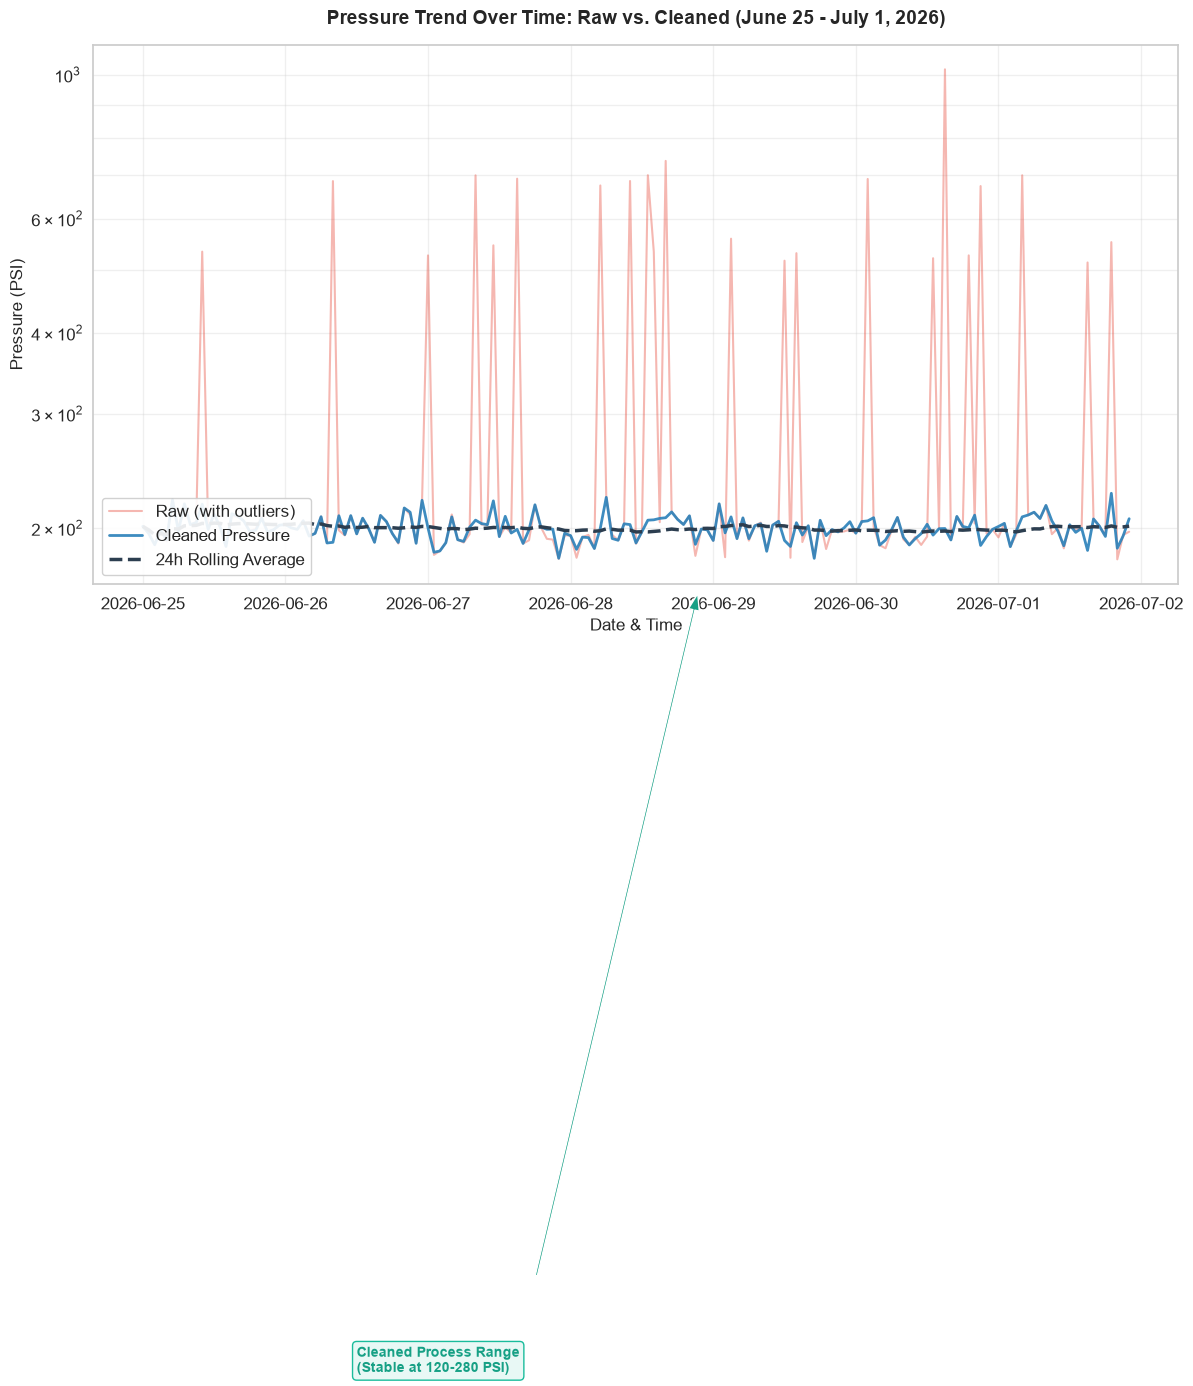

In [7]:
# Resample raw data to hourly for clean alignment with the cleaned series
df_raw_ts = df_raw.copy()
df_raw_ts['timestamp'] = pd.to_datetime(df_raw_ts['timestamp'], errors='coerce')
# Align the single date typo in the raw data so it visualizes chronologically
df_raw_ts.loc[df_raw_ts['timestamp'].dt.month == 1, 'timestamp'] = df_raw_ts.loc[df_raw_ts['timestamp'].dt.month == 1, 'timestamp'].apply(
    lambda x: x.replace(month=7, day=1) if pd.notna(x) else x
)
df_raw_hourly = df_raw_ts.set_index('timestamp').resample('1h').mean(numeric_only=True)

# Plotting
fig, ax = plt.subplots(figsize=(14, 7))

# Plot Raw pressure (which contains huge outliers)
ax.plot(df_raw_hourly.index, df_raw_hourly['Pressure_PSI'], 
        color='#e74c3c', alpha=0.4, label='Raw (with outliers)', linewidth=1.5)

# Plot Cleaned pressure
ax.plot(df_hourly.index, df_hourly['Pressure_PSI'], 
        color='#2980b9', alpha=0.9, label='Cleaned Pressure', linewidth=2)

# Plot 24h rolling average
ax.plot(df_hourly.index, df_hourly['Pressure_24h_Rolling'], 
        color='#2c3e50', linestyle='--', label='24h Rolling Average', linewidth=2.5)

# Formatting
ax.set_title('Pressure Trend Over Time: Raw vs. Cleaned (June 25 - July 1, 2026)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date & Time', fontsize=12)
ax.set_ylabel('Pressure (PSI)', fontsize=12)
ax.set_yscale('log') # Log scale because of massive outlier differences (15k PSI)
ax.grid(True, which="both", ls="-", alpha=0.3)

# Annotations
# 1. Highlighting outlier spikes
ax.annotate('Sensor Outliers\n(Spikes up to 15,000 PSI)', 
            xy=(pd.Timestamp('2026-06-30 15:00:00'), 15000),
            xytext=(pd.Timestamp('2026-06-27 12:00:00'), 1000),
            arrowprops=dict(facecolor='#c0392b', shrink=0.08, width=1.5, headwidth=8),
            fontsize=10, color='#c0392b', weight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="#fdeae8", ec="#e74c3c", lw=1))

# 2. Highlighting cleaned range
ax.annotate('Cleaned Process Range\n(Stable at 120-280 PSI)', 
            xy=(pd.Timestamp('2026-06-29 00:00:00'), 200),
            xytext=(pd.Timestamp('2026-06-26 12:00:00'), 10),
            arrowprops=dict(facecolor='#16a085', shrink=0.08, width=1.5, headwidth=8),
            fontsize=10, color='#16a085', weight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="#e8f8f5", ec="#1abc9c", lw=1))

ax.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()

# Save the chart
chart_output_path = 'pressure_comparison.png'
plt.savefig(chart_output_path, dpi=300)
print(f"Chart saved successfully to {chart_output_path}")

In [9]:
import os
print(os.getcwd())

C:\Users\kipng\Downloads
